# Fine tune sentence transformer 

This notebook implements the steps to finetune the 'all-MiniLM-L6-v2' sentence transformer. It is fine-tuned using the training dataset generated in '1_0_5_rule_based_labelling.ipynb' - which consists of 200,000 pairs of sentences derived from public objections to planning applications. 

The data is loaded directly from the repo on Zenodo: [https://zenodo.org/records/15583249](https://zenodo.org/records/15583249). Of the 200,000 pairs, 100,000 are positive pairs, and 100,000 are neutral pairs. The positive pairs have soft labels - hence Cosine Similarity is used for training since it works well with floats. 

The model is trained using the built in functions from [sentence_transformers](https://sbert.net/docs/sentence_transformer/training_overview.html#training-arguments).

The model is saved remotely to HuggingFace [https://huggingface.co/Bea-Taylor/objection_fine_tuned](https://huggingface.co/Bea-Taylor/objection_fine_tuned). The model is evaluated before and after fine tuning. 


In [1]:
import requests
import pickle
from io import BytesIO

import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset 

from sklearn.model_selection import train_test_split
import torch
from sentence_transformers import SentenceTransformer, losses, SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator, SimilarityFunction

# Configure logging
import logging
logging.basicConfig(format='%(asctime)s - %(message)s',
                    level=logging.INFO)

/opt/conda/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load a model to fine-tune
The baseline model used here is the 'all-MiniLM-L6-v2'.

In [2]:
model = SentenceTransformer('all-MiniLM-L6-v2')

2025-06-05 15:02:04,327 - Use pytorch device_name: cuda:0
2025-06-05 15:02:04,329 - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


In [3]:
# Check if GPU is available and if so move model to GPU
if torch.cuda.is_available():
    model = model.to('cuda')
    print("Using GPU for training")
else:
    print("GPU not available, using CPU")

Using GPU for training


### Load data from Zenodo

In [4]:
record_id = "15583249"
access_token = "AUn57Ykztzzg7Cy8MdtAFEzGc53A4StqkVAYehmIa8lXe03evN1rHvV7GwZ6" 

api_url = f"https://zenodo.org/api/records/{record_id}"
headers = {"Authorization": f"Bearer {access_token}"}

# Get metadata
response = requests.get(api_url, headers=headers)
response.raise_for_status()
metadata = response.json()

# Find .pkl file and get the 'self' link
file_url = None
filename = None
for file in metadata.get('files', []):
    if file['key'].endswith('.pkl'):
        filename = file['key']
        file_url = file['links']['self']
        break

if not file_url:
    raise FileNotFoundError("No .pkl file found in the record.")

print(f"Downloading {filename} from {file_url}")

# Download file with auth header
file_response = requests.get(file_url, headers=headers)
file_response.raise_for_status()

# Load pickle from bytes
data = pickle.load(BytesIO(file_response.content))

print("Pickle file loaded:", type(data))


Pickle file loaded: <class 'list'>


### Split into a train and evaluation set

In [5]:
df = pd.DataFrame([{
    "text1": example.texts[0],
    "text2": example.texts[1],
    "label": example.label
} for example in data])

dataset = Dataset.from_pandas(df)

dataset_split = dataset.train_test_split(test_size=0.1, seed=42)
dataset_train = dataset_split['train']
dataset_eval = dataset_split['test']

In [6]:
print(f"Number of training examples: {len(dataset_train)}")
print(f"Number of evaluation examples: {len(dataset_eval)}")

Number of training examples: 180000
Number of evaluation examples: 20000


### Define loss function

In [7]:
train_loss = losses.CosineSimilarityLoss(model=model)

### Specify training arguments

In [ ]:
# note: output_dir is the local location to save the file at
args = SentenceTransformerTrainingArguments(
    output_dir="../outputs/sentence_transformer_model/objection_tuned_ST",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    fp16=True, 
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    logging_steps=100,
    run_name="objection_tuned_ST"
)

### Define evaluator 

In [9]:
dev_evaluator = EmbeddingSimilarityEvaluator(
    sentences1=dataset_eval["text1"],
    sentences2=dataset_eval["text2"],
    scores=dataset_eval["label"],
    main_similarity=SimilarityFunction.COSINE,
    name="10% evaluation set",
)

### Evaluate the base model 

In [10]:
dev_evaluator(model)

2025-06-05 15:03:08,857 - EmbeddingSimilarityEvaluator: Evaluating the model on the 10% evaluation set dataset:
2025-06-05 15:03:27,270 - Cosine-Similarity :	Pearson: 0.3563	Spearman: 0.3501


{'10% evaluation set_pearson_cosine': 0.35626862948380655,
 '10% evaluation set_spearman_cosine': 0.35005565142718625}

### Train the model 
Note: this takes around 1hr 30 minutes to run on the GPU. 

In [11]:
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=dataset_train,
    eval_dataset=dataset_eval,
    evaluator=dev_evaluator,
    loss=train_loss
)

In [12]:
trained = trainer.train()

Step,Training Loss,Validation Loss,10% evaluation set Pearson Cosine,10% evaluation set Spearman Cosine
100,0.108200,0.111334,0.402177,0.392810


2025-06-05 15:04:02,502 - EmbeddingSimilarityEvaluator: Evaluating the model on the 10% evaluation set dataset in epoch 0.008888888888888889 after 100 steps:
2025-06-05 15:04:23,964 - Cosine-Similarity :	Pearson: 0.4022	Spearman: 0.3928
2025-06-05 15:04:23,974 - Saving model checkpoint to ../outputs/models/objection_tuned_ST/checkpoint-100
2025-06-05 15:04:23,975 - Save model to ../outputs/models/objection_tuned_ST/checkpoint-100


KeyboardInterrupt: 

### Plot the learning rate 

In [ ]:
# Load the logged metrics
log_file_path = '../outputs/sentence_transformer_model/objection_tuned_ST/eval/similarity_evaluation_10% evaluation set_results.csv'

log_df = pd.read_csv(log_file_path)

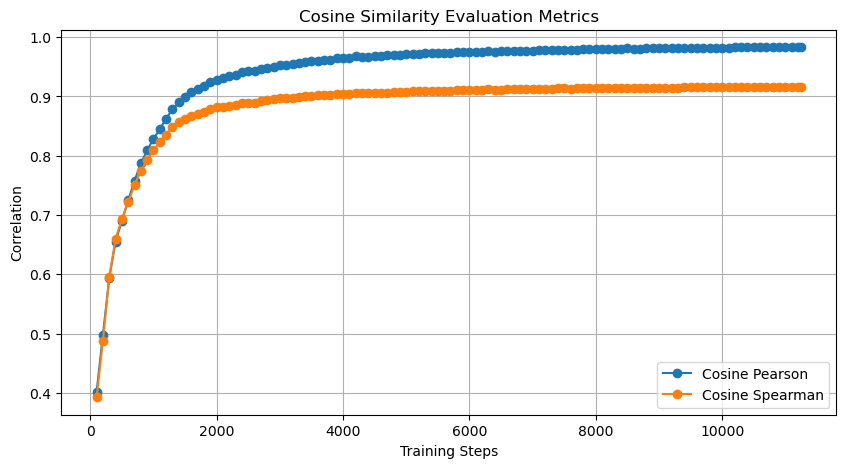

In [ ]:
# plot steps and the cosine pearson and spearman correlation
plt.figure(figsize=(10, 5))
plt.plot(log_df['steps'], log_df['cosine_pearson'], label='Cosine Pearson', marker='o')
plt.plot(log_df['steps'], log_df['cosine_spearman'], label='Cosine Spearman', marker='o')
plt.xlabel('Training Steps')
plt.ylabel('Correlation')
plt.title('Cosine Similarity Evaluation Metrics')
plt.legend()
plt.grid()

In [ ]:
# plt.savefig('../outputs/sentence_transformer_model/objection_tuned_ST/eval/similarity_evaluation_plot.png')

<Figure size 640x480 with 0 Axes>

In [ ]:
dev_evaluator(model)

2025-06-05 11:05:20,469 - EmbeddingSimilarityEvaluator: Evaluating the model on the 10% evaluation set dataset:
2025-06-05 11:05:41,141 - Cosine-Similarity :	Pearson: 0.9829	Spearman: 0.9159


{'10% evaluation set_pearson_cosine': 0.982945476483903,
 '10% evaluation set_spearman_cosine': 0.9159112066033667}

### Save the model to HuggingFace hub 

note: this requires you to already be logged into HuggingFace (using a User Access Token and the command ```huggingface-cli login```). 

In [ ]:
model.push_to_hub(
    "objection_fine_tuned_4"
    )

HfHubHTTPError: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-68417a05-0a1a1f2546bfedff79f4f4a8;d3cf3d80-1717-4110-a67e-46bcaedba73b)

You already created this model repo